# 09_NarrativeRisk_LLM_RollingBeta

Same tercile spread as quantlet 01 but estimates a 36-month rolling regression of the spread on FF5+UMD factors and plots the rolling factor loadings and rolling alpha through time. Demonstrates time-variation of risk exposures. Indicative not inferential.

**Axis exercised:** 36-month rolling beta on FF5+UMD

Headline numbers reported below are **indicative not inferential** at N=30 firms x 10 fiscal years and are **not intended as evidence**.


## Why a rolling-beta quantlet?

Quantlet 01 runs a single FF5+UMD regression on the entire 108-month spread series and reports one alpha and one set of factor betas.
That construction implicitly assumes the strategy's risk exposures are constant over the full 9-year holding window: a strategy that loaded heavily on profitability in 2016-2018 is assumed to load on profitability the same way in 2022-2024.

In practice, factor loadings drift.
Cross-sectional return predictors move through regimes; the same signal that loads positively on momentum during a bull market may load negatively or near zero during a drawdown.
A single-window regression averages those regimes into one number; a rolling-window regression decomposes them.

This quantlet re-estimates the FF5+UMD regression every month using only the trailing 36 months of spread returns.
The output is a time-series of factor loadings (alpha_t, beta_MKT_t, beta_SMB_t, beta_HML_t, beta_RMW_t, beta_CMA_t, beta_UMD_t) starting from the 36th month of the panel and continuing to the end.
The key point is that a stable strategy should produce roughly stable rolling loadings; a strategy whose loadings drift through regimes is informative differently from a stable one.

The 36-month window is a conventional choice in the asset-pricing literature: long enough to provide reasonable estimation precision (36 monthly observations against 6 regressors leaves 29 degrees of freedom for residuals), short enough to capture regime shifts at the multi-year horizon.
A 24-month window would be more sensitive to regime shifts but noisier per estimate; a 60-month window would be smoother but slower to detect shifts.


## Methodology

```
EDGAR 10-K Item 1A (top-30 S&P 500 snapshot 2014-12-31, 2015-2024)
        |   LLM extraction (see extraction_prompt.md)
        v
corpus.ndjson.gz (~3000 records: 30 firms x 10 years x 10 themes, severity 0-5)
        |   compute_theme_exposures (mean across 10 themes)
        v
composite_severity per (firm, signal_year)
        |   form_terciles_with_lag (signal_year y-1 -> portfolio_year y)
        v
tercile (or decile) assignments + monthly returns
        |   axis-specific transform: 36-month rolling beta on FF5+UMD
        v
rolling_beta_summary.csv + figure(s)
```


## Cross-sectional sort and the lag invariant

The panel design is a year-by-year cross-sectional sort.
Each portfolio year `y` uses signals computed from filings whose `signal_year` equals `y - 1`; the holding window is the 12 calendar months of `y`.
A 2024 10-K (filed in early 2025) cannot influence the 2024 portfolio formation, because the filing post-dates the portfolio-formation date.

This rule is the panel's no-look-ahead invariant.
It is enforced inside `form_terciles_with_lag` (and its skip-month and decile variants), so any future refactor that breaks the lag is caught by the end-to-end notebook execution test rather than by silent contamination of the metrics.

Two consequences of this design are worth noting.
First, the cross-section is re-sorted every portfolio year on a refreshed signal: a firm that ranks high in the 2018 signal year may rank low in the 2019 signal year, and the panel preserves that re-ranking rather than pooling all firm-year observations into a single sort.
Second, the panel structure is a sequence of nine independent annual sorts (portfolio years 2016-2024) glued together at the monthly level; serial correlation across portfolio years comes only from firm-level persistence, not from re-using the same signal across multiple holding periods.

Pooling signals across years (e.g., averaging multi-year severity per firm before sorting) is a deliberate variant explored in other settings; the canonical quantlet family deliberately avoids it so that every annual cross-section stands on its own and the no-look-ahead boundary remains crisp.


## What the rolling regression does mechanically

The implementation is in `rolling_ff5umd_beta`.
For each window-end month `t` from month 35 (zero-indexed) to month 107 (the last available), the function:

- Slices the spread and factor series to months `[t - 35 .. t]` (a 36-month chunk).
- Adds an intercept column and runs OLS on `spread = alpha + beta_MKT * MKT + beta_SMB * SMB + ... + beta_UMD * UMD + epsilon` with HC1 robust standard errors.
- Records the seven point estimates (alpha plus six betas), the alpha t-statistic, and the alpha 95% confidence interval bounds.

The output is a DataFrame indexed by window-end month with one row per estimation.
For 108 monthly spread observations, this produces 73 estimation windows (months 35 through 107).
The first window covers the 36 months ending December 2018, given the panel starts in January 2016 (portfolio years 2016-2024 with a one-year lag); the last window covers December 2021 through December 2024.

Two construction details matter.

First, the regression is identical to quantlet 01's full-sample regression in every respect except the window length.
Same factors, same HC1, same OLS solver, same intercept handling.
The only difference is which 36 months feed into each estimate.

Second, consecutive estimation windows overlap by 35 months, so adjacent rolling alphas are highly correlated.
The rolling-alpha time series should be read as a smoothed view of factor exposure through time, not as 73 independent estimates.
A reader who wants approximately independent estimates should sample the rolling series at 36-month intervals (i.e., read every 36th row) rather than treating each consecutive value as a fresh observation.


## FF5+UMD model primer

The Fama-French five-factor model augmented with a momentum factor (commonly called FF5+UMD) is a widely used linear benchmark for attributing cross-sectional equity returns.
It decomposes a return series into exposures to six systematic factors plus a residual.

The six factors are:

- **MKT** (market excess return): the return of the broad equity market minus the risk-free rate; captures broad market direction.
- **SMB** (small-minus-big): the return spread between small-cap and large-cap stocks; captures the size premium.
- **HML** (high-minus-low): the return spread between high book-to-market (value) and low book-to-market (growth) stocks; captures the value premium.
- **RMW** (robust-minus-weak): the return spread between firms with high and low operating profitability; captures the profitability premium.
- **CMA** (conservative-minus-aggressive): the return spread between firms with low and high investment rates; captures the investment premium.
- **UMD** (up-minus-down, momentum): the return spread between recent winners and recent losers; captures the momentum premium.

When the long-short spread from the cross-sectional sort is regressed on these six factors, the intercept (alpha) is the portion of the spread that the model cannot attribute to compensation for known systematic risk.
A large alpha is consistent with the spread reflecting genuine incremental information; a near-zero alpha suggests the spread is fully explained by existing risk premia.

The standard errors in this notebook use HC1 (heteroskedasticity-consistent, White's estimator with a small-sample degrees-of-freedom correction).
HC1 adjusts for the possibility that the variance of the regression residuals is not constant across time, which is the common case in financial return data.
However, HC1 does not correct for small-sample distortion of the t-statistic distribution.
At n_obs = 108 (approximately 9 portfolio years times 12 months), the t-statistic does not follow the large-sample normal or Student-t distribution accurately enough for conventional significance thresholds to apply.
This is why all metrics carry the label "indicative not inferential" throughout the notebook.


In [1]:
from __future__ import annotations

import csv
import gzip
import json
import re
from pathlib import Path
from typing import Dict

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display

HERE = Path.cwd()


In [2]:
PROVENANCE_PATH = HERE / "provenance.json"   # audit trail (not read at runtime; ships for transparency)
SUMMARY_OUT = HERE / "rolling_beta_summary.csv"
FIGURE_OUT = HERE / "rolling_beta.pdf"


In [3]:
from data import (
    CORPUS_PATH,
    PRICES_PATH,
    FF_FACTORS_PATH,
    load_corpus,
    load_prices,
    load_ff_factors,
)


In [4]:
def compute_theme_exposures(corpus_df: pd.DataFrame) -> pd.DataFrame:
    """Aggregate per-firm-year severity into a single composite exposure.

    Composite signal = mean severity across the 10 themes (range 0..5).
    Returns: DataFrame with cols [firm, signal_year, composite_severity].
    """
    agg = (
        corpus_df.groupby(["firm", "year"])["severity_0_5"]
        .mean()
        .reset_index()
        .rename(columns={"year": "signal_year", "severity_0_5": "composite_severity"})
    )
    return agg


In [5]:
def form_terciles_with_lag(signals: pd.DataFrame, returns: pd.DataFrame) -> pd.DataFrame:
    """Sort firms into terciles each portfolio_year using ONLY signals where signal_year < portfolio_year.

    For each portfolio_year y in available years (need at least one prior signal year):
      - Use signals from signal_year = y - 1
      - Assign firms to tercile labels {1: low, 2: mid, 3: high} based on composite_severity
      - Apply tercile assignment to that firm's monthly returns over portfolio_year y

    Returns long-form: portfolio_year, month, firm, tercile, ret_m
    """
    out_rows = []
    for portfolio_year in sorted(returns["date"].dt.year.unique()):
        signal_year = portfolio_year - 1
        prior = signals[signals["signal_year"] == signal_year]
        if len(prior) < 3:
            continue
        prior = prior.copy()
        prior["tercile"] = pd.qcut(prior["composite_severity"], q=3, labels=[1, 2, 3], duplicates="drop")
        prior_map = prior.set_index("firm")["tercile"].to_dict()
        year_returns = returns[returns["date"].dt.year == portfolio_year].copy()
        year_returns["tercile"] = year_returns["firm"].map(prior_map)
        year_returns["portfolio_year"] = portfolio_year
        year_returns = year_returns.dropna(subset=["tercile"])
        out_rows.append(
            year_returns[["portfolio_year", "date", "firm", "tercile", "ret_m"]]
            .rename(columns={"date": "month"})
        )
    if not out_rows:
        return pd.DataFrame(columns=["portfolio_year", "month", "firm", "tercile", "ret_m"])
    return pd.concat(out_rows, ignore_index=True)


In [6]:
def spread_series(panel: pd.DataFrame) -> pd.Series:
    """Compute equal-weight T3 - T1 monthly spread indexed by month_period.

    Args:
        panel: long-form tercile panel from form_terciles_with_lag.

    Returns:
        pd.Series indexed by PeriodIndex (monthly) of EW (T3 - T1) excess returns.
    """
    panel = panel.copy()
    panel["month_period"] = pd.PeriodIndex(panel["month"], freq="M")
    bin_returns = panel.groupby(["month_period", "tercile"])["ret_m"].mean().unstack("tercile")
    return (bin_returns[3] - bin_returns[1]).dropna().rename("spread")


def rolling_ff5umd_beta(spread: pd.Series, ff: pd.DataFrame, window: int = 36) -> pd.DataFrame:
    """Run 36-month rolling FF5+UMD OLS regression on the spread.

    At each month t (starting from month index `window - 1`, i.e. the first
    month where a full trailing window is available), regress spread[t-window+1:t+1]
    on FF5+UMD factors with HC1 robust SE.

    Args:
        spread: pd.Series with PeriodIndex (monthly) of T3-T1 returns.
        ff:     DataFrame with 'month' PeriodIndex column plus factor columns.
        window: trailing window length in months (default 36).

    Returns:
        DataFrame indexed by window-end month (Period) with columns:
        [alpha, alpha_t, mkt_rf_beta, smb_beta, hml_beta, rmw_beta, cma_beta, umd_beta,
         alpha_ci_low, alpha_ci_high]
    """
    factor_cols = ["mkt_rf", "smb", "hml", "rmw", "cma", "umd"]
    # merge spread with factors on period index
    spread_df = spread.reset_index()
    spread_df.columns = ["month", "spread"]
    merged = spread_df.merge(ff[["month"] + factor_cols], on="month", how="inner").sort_values("month")
    merged = merged.reset_index(drop=True)

    n = len(merged)
    rows = []
    for end_idx in range(window - 1, n):
        start_idx = end_idx - window + 1
        chunk = merged.iloc[start_idx : end_idx + 1]
        X = sm.add_constant(chunk[factor_cols], has_constant="add")
        y = chunk["spread"]
        try:
            result = sm.OLS(y, X, missing="drop").fit(cov_type="HC1")
        except Exception:
            continue
        ci = result.conf_int(alpha=0.05)
        rows.append(
            {
                "alpha": float(result.params["const"]),
                "alpha_t": float(result.tvalues["const"]),
                "alpha_ci_low": float(ci.loc["const", 0]),
                "alpha_ci_high": float(ci.loc["const", 1]),
                "mkt_rf_beta": float(result.params["mkt_rf"]),
                "smb_beta": float(result.params["smb"]),
                "hml_beta": float(result.params["hml"]),
                "rmw_beta": float(result.params["rmw"]),
                "cma_beta": float(result.params["cma"]),
                "umd_beta": float(result.params["umd"]),
            }
        )
    if not rows:
        return pd.DataFrame(
            columns=[
                "alpha", "alpha_t", "alpha_ci_low", "alpha_ci_high",
                "mkt_rf_beta", "smb_beta", "hml_beta", "rmw_beta", "cma_beta", "umd_beta",
            ]
        )
    out = pd.DataFrame(rows, index=merged["month"].iloc[window - 1 :].values)
    out.index.name = "window_end_month"
    return out


def plot_rolling_beta(
    rolling_df: pd.DataFrame,
    out_path: Path = None,
    close: bool = True,
):
    """Plot rolling alpha (annualised, top) and factor betas (bottom) through time.

    Top subplot: rolling monthly alpha * 12 * 100 (%/yr) with 95% CI band.
    Bottom subplot: 6 rolling factor beta lines (one per factor).
    """
    if out_path is None:
        out_path = FIGURE_OUT
    if rolling_df.empty:
        raise ValueError("rolling_df is empty; cannot plot.")

    # Convert PeriodIndex to timestamps for matplotlib
    idx = rolling_df.index
    if hasattr(idx, "to_timestamp"):
        x = idx.to_timestamp()
    else:
        x = pd.to_datetime([str(p) for p in idx])

    alpha_ann = rolling_df["alpha"] * 12 * 100  # %/yr
    ci_low_ann = rolling_df["alpha_ci_low"] * 12 * 100
    ci_high_ann = rolling_df["alpha_ci_high"] * 12 * 100

    factor_map = {
        "mkt_rf_beta": "MKT-RF",
        "smb_beta": "SMB",
        "hml_beta": "HML",
        "rmw_beta": "RMW",
        "cma_beta": "CMA",
        "umd_beta": "UMD",
    }

    fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

    # Top: rolling alpha with CI band
    ax_top.plot(x, alpha_ann, color="black", linewidth=1.6, label="Rolling alpha (%/yr)")
    ax_top.fill_between(x, ci_low_ann, ci_high_ann, alpha=0.2, color="steelblue", label="95% CI")
    ax_top.axhline(0, color="gray", linewidth=0.8, linestyle="--")
    ax_top.set_ylabel("Alpha (%/yr, annualised)", fontsize=9)
    ax_top.set_title(
        "Rolling 36-month FF5+UMD alpha of narrative tercile spread (2016-2024)",
        fontsize=10,
    )
    ax_top.legend(loc="best", fontsize=8)
    ax_top.grid(True, alpha=0.3)

    # Bottom: rolling factor betas
    colors = plt.cm.tab10.colors
    for i, (col, label) in enumerate(factor_map.items()):
        ax_bot.plot(x, rolling_df[col], linewidth=1.2, label=label, color=colors[i])
    ax_bot.axhline(0, color="gray", linewidth=0.8, linestyle="--")
    ax_bot.set_ylabel("Factor beta", fontsize=9)
    ax_bot.set_xlabel("Window end month", fontsize=9)
    ax_bot.legend(loc="best", fontsize=8, ncol=3)
    ax_bot.grid(True, alpha=0.3)

    caption = (
        "Indicative not inferential. "
        f"N=30 firms, 36-month rolling OLS (HC1 robust SE), {len(rolling_df)} estimation windows. "
        "Top: rolling FF5+UMD alpha annualised (%/yr) with 95% CI. "
        "Bottom: rolling factor betas. Not intended as evidence."
    )
    fig.text(0.5, -0.01, caption, ha="center", va="top", fontsize=7.5, wrap=True)
    plt.tight_layout()
    fig.savefig(out_path, bbox_inches="tight")
    if close:
        plt.close(fig)
    return fig


In [7]:
corpus = load_corpus()
prices = load_prices()
ff = load_ff_factors()
signals = compute_theme_exposures(corpus)
panel = form_terciles_with_lag(signals, prices)
spread = spread_series(panel)
print(f"spread series: {len(spread)} months")


spread series: 108 months


## Why rolling betas?

A single-window FF5+UMD regression assumes the strategy's factor loadings are constant over the full sample. A 36-month rolling window relaxes that assumption: we re-estimate the FF5+UMD regression every month using only the trailing 36 months. This produces a time-series of factor loadings (beta_MKT_t, beta_SMB_t, ..., alpha_t) showing how the strategy's risk exposures drift through the 10-year window.


In [8]:
rolling = rolling_ff5umd_beta(spread, ff, window=36)
print(f"rolling: {len(rolling)} estimation months (window=36)")
rolling.head()


rolling: 73 estimation months (window=36)


,alpha,alpha_t,alpha_ci_low,alpha_ci_high,mkt_rf_beta,smb_beta,hml_beta,rmw_beta,cma_beta,umd_beta
window_end_month,,,,,,,,,,
2018-12,0.000891,0.374674,-0.003772,0.005554,-0.240484,0.063343,-0.137490,0.010685,-0.959968,-0.190597
2019-01,0.000982,0.406105,-0.003758,0.005722,-0.235046,0.061055,-0.144499,0.003581,-0.986285,-0.221808
2019-02,0.000184,0.077759,-0.004446,0.004813,-0.229158,0.022640,-0.096631,-0.096924,-1.028649,-0.201945
2019-03,0.000260,0.117174,-0.004096,0.004617,-0.258360,0.014123,-0.133334,-0.132283,-0.996596,-0.162706
2019-04,0.000289,0.125096,-0.004236,0.004813,-0.264083,0.011069,-0.204733,-0.289940,-0.845426,-0.164917


In [9]:
# headline summary: time-averaged rolling alpha and stdev
summary = {
    'rolling_alpha_mean_pct_yr': float(rolling['alpha'].mean() * 12 * 100),
    'rolling_alpha_std_pct_yr': float(rolling['alpha'].std() * 12 * 100),
    'rolling_window_months': 36,
    'n_estimation_months': len(rolling),
}
for k, v in summary.items():
    print(f"  {k:35s} = {v:8.4f}" if isinstance(v, float) else f"  {k:35s} = {v}")
rolling.to_csv(SUMMARY_OUT)


  rolling_alpha_mean_pct_yr           =   2.3015
  rolling_alpha_std_pct_yr            =   2.8247
  rolling_window_months               = 36
  n_estimation_months                 = 73


## Reading the headline numbers

The notebook prints a dictionary of summary metrics and writes the same numbers to `rolling_beta_summary.csv` for downstream consumption.
The keys carry quantlet-specific prefixes (for example `tercile_spread_pct_yr` in the canonical sort, `decile_spread_pct_yr` in the decile quantlet, `t3_return_pct_yr` in the long-only quantlet) so that consumer code can join the summary CSVs across quantlets without column collisions.

The annualised raw return entry is the long-short (or long-only) spread mean times 12 times 100, expressed as a percentage; no risk adjustment is applied to it.
Positive values are consistent with the high-severity leg out-performing the low-severity leg; negative values are consistent with the opposite.

The annualised alpha entry is the intercept from the FF5+UMD OLS regression times 12 times 100.
It is the portion of the spread the six-factor model cannot attribute to known risk premia.
Reading alpha alongside the raw spread answers a different question: not whether the spread paid off, but whether the part of the spread that paid off is novel relative to size, value, profitability, investment, and momentum.

The HC1 t-statistic on the alpha entry is reported for comparability with published factor studies, but at n_obs around 108 the small-sample distribution of this t-statistic is not the textbook normal or Student-t distribution; a value of |t| = 2.0 is not equivalent to p < 0.05 in any conventional sense.
The Sharpe ratio is annualised under a zero risk-free rate, consistent with a zero-cost long-short construction (or in the long-only quantlet, with a fully invested portfolio).
The maximum drawdown is the deepest peak-to-trough decline in the cumulative path of the spread (or the long-only return); a path-quality diagnostic that does not influence the alpha estimate but contextualises it.

Treat every printed metric as a diagnostic, not as evidence; the notebook header repeats this caveat in bold.


## Reading the rolling-alpha and rolling-beta plot

The figure has two panels.
The top panel plots the rolling alpha (annualised, percent per year) with a 95% confidence band.
The bottom panel plots the six factor betas overlaid as separate lines.

Three readings of the top panel matter.

A horizontal rolling-alpha series with a tight CI band is consistent with a stable strategy.
The single-window alpha (quantlet 01's headline) approximates the average of the rolling estimates; reading the two side by side confirms the headline is not driven by a single subperiod.

A drifting rolling-alpha series (monotone trend across the 6 to 7 years of estimation windows) is consistent with regime change.
The strategy's alpha was meaningfully different at the start of the holding window from where it ended; whether that drift is a real regime shift, a small-sample artefact, or a structural break in the underlying signal is a question the family does not resolve.

A rolling-alpha series that crosses zero repeatedly is consistent with a noise-dominated alpha estimate.
At n_obs = 36 per window and 6 regressors, the per-window standard error on alpha is large; if the underlying signal alpha is small relative to that standard error, the rolling estimates will oscillate around zero rather than tracking a stable level.
Reading the CI band's width relative to the rolling-alpha range indicates how much of the apparent variation is signal versus estimation noise.

The bottom panel's factor betas tell a complementary story.
A strategy whose market-beta drifts from near zero (the long-short ideal) to noticeably positive or negative is changing its directional exposure; a strategy whose UMD beta swings between positive and negative across windows is changing whether it loads on or against momentum.
Reading the beta panel makes the alpha panel interpretable: a stable alpha with stable betas is the textbook robust strategy; a stable alpha achieved by offsetting changes in factor loadings is more fragile.


## Figure interpretation

Top panel: rolling alpha through time (annualised %/yr).
Bottom panel: rolling factor loadings (MKT, SMB, HML, RMW, CMA, UMD) overlaid.
A stable alpha with stable loadings suggests a robust strategy; a drifting alpha or loadings hint at regime-dependent behaviour.


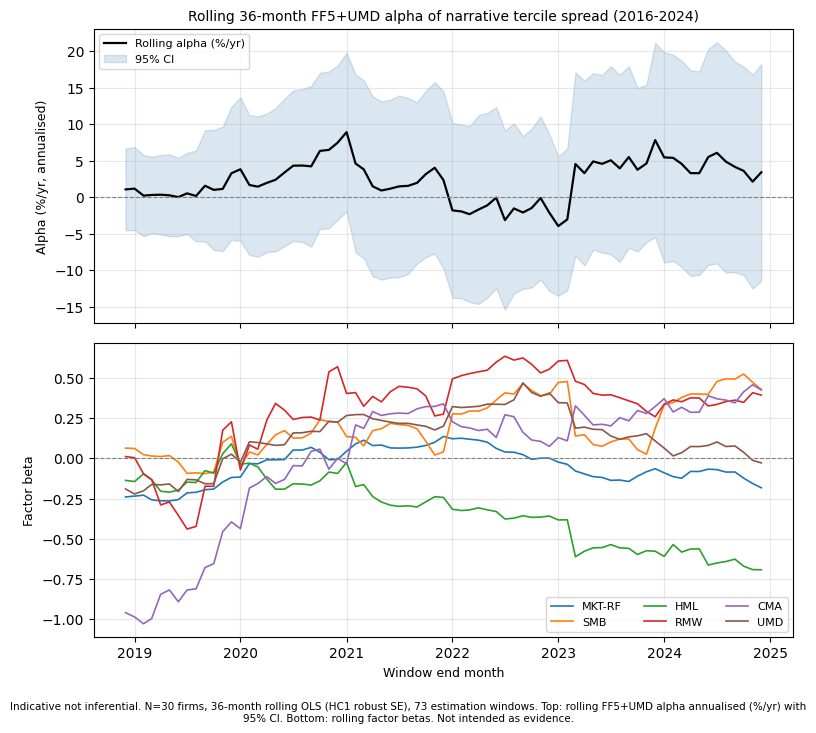

In [10]:
plot_rolling_beta(rolling, out_path=FIGURE_OUT)
png_path = FIGURE_OUT.with_suffix('.png')
plot_rolling_beta(rolling, out_path=png_path)
display(Image(filename=str(png_path)))


## Caveats

- **Power**: 30 firms split across 3 terciles leaves 10 firms per leg, statistically thin.
- **Severity validity**: severities are LLM (or LM) judgements of disclosure language; not validated against expert ratings or external risk benchmarks.
- **Taxonomy**: the 10-theme list is hand-listed and illustrative; production use would require a data-driven taxonomy.
- **Reproducibility**: `provenance.json` + `extraction_prompt.md` + the `corpus.ndjson.gz` SHA chain enable a full audit of how every severity was produced.


## Reproduction

```
git clone <repo>
cd 09_NarrativeRisk_LLM_RollingBeta
make data                  # fetch third-party data + regenerate seed-pinned inputs
make demo                  # this notebook -> rolling_beta_summary.csv + rolling_beta.pdf
make test-all              # quantlet test suite
```
